# Modelling

Continuing after the initial exploration `initial_exploration.ipynb`.

There we did some basic and kindof unstructured data exploration, looking at things such which features and feature-pairs that a cross-validation on decision trees found important. 

Here, we want to do things more structured, so that we can perform more pragmatic modelling without as much effort.

## Imports & Setup

In [1]:
# Import modules
import numpy as np
import pandas as pd
import random
import json
from dataclasses import dataclass, field, replace

# We use seaborn for prettier plots
import matplotlib.pyplot as plt
import seaborn as sns

# To get typehints
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from numpy.typing import NDArray
from typing import *  # bad practice but I dont care

# sklearn: the preprocessing and model selection machinery
from sklearn.base import clone
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    QuantileTransformer,
    OneHotEncoder,
    FunctionTransformer,
    PolynomialFeatures,
)
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict,
    validation_curve,
    learning_curve,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from scipy import stats

# sklearn: the methods from the lab instructions
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.svm import SVC
from xgboost import XGBClassifier

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
sns.set_theme()

PALETTE = {0: "red", 1: "blue"}
pd.set_option("display.width", 160, "display.max_columns", 30)

## Data

In [2]:
# Load data, same as in the exploration
train = pd.read_csv("labs/lab_1_music_taste_prediction/data/training_data.csv")
test = pd.read_csv("labs/lab_1_music_taste_prediction/data/songs_to_classify.csv")

LABEL = "label"
DISCRETE_COLS = ["key", "mode", "time_signature"]
NUMERIC_COLS = [col for col in train.columns if col not in DISCRETE_COLS + [LABEL]]

# We skipped this in the initail exploration, but its important to drop duplicates
# b.c. if a duplicated song ends up in both train and validation, it could make the
# results less trustworthhy
n_before = len(train)
train = train.drop_duplicates().reset_index(drop=True)
print(
    f"dropped {n_before - len(train)} duplicate rows, {len(train)} songs left, {train[LABEL].mean():.3f} liked"
)

train_features = train.drop(LABEL, axis=1)
train_labels = train[LABEL]
test_features = test[train_features.columns]  # same column order as train
print(train_features.shape, test_features.shape)

dropped 14 duplicate rows, 736 songs left, 0.602 liked
(736, 13) (200, 13)


## Decisions

### Metric
accuracy (because that is what the leaderboard measures). ROC AUC are still useful, but accuracy takes precidence

### Validation & Hyperparams-tuning

We use nested cross validation with stratified folds (preserves class proportions)

5 outer loops * 5 inner loops = 25 splits

We use the same random seed, so every method is scored on exactly the same 25 splits so comparisons are paired.

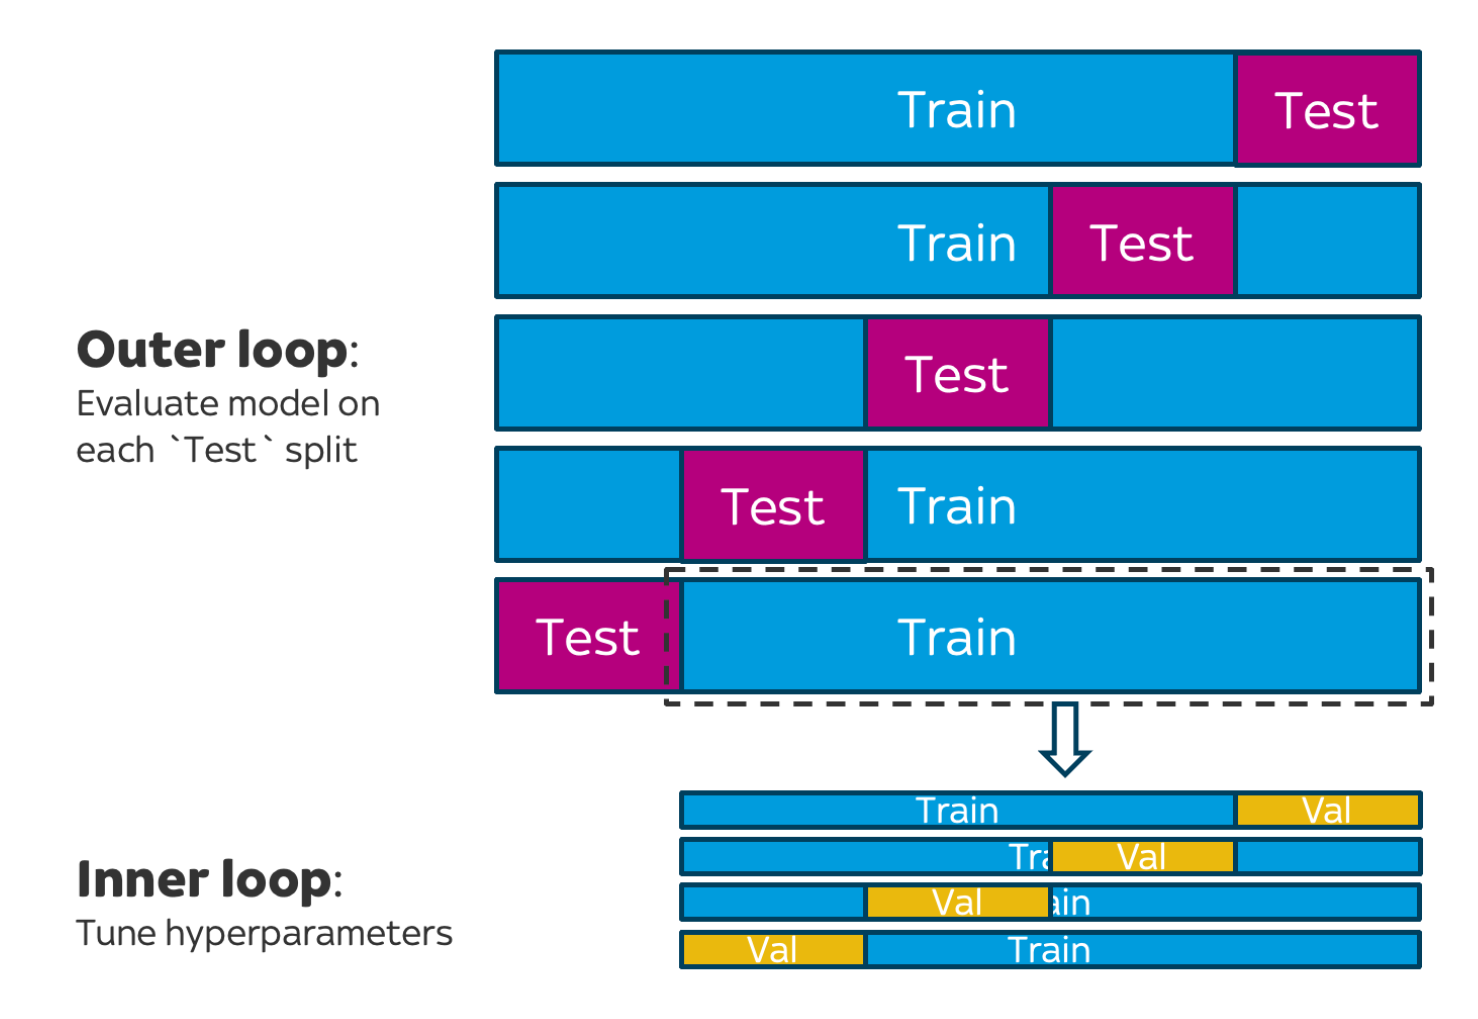
(https://towardsdatascience.com/two-common-pitfalls-to-avoid-when-doing-cross-validation-c68ed79c0e4e/)

Because the splits share most of their songs, we use the Nadeau-Bengio correction (corrects standard error) (https://metricgate.com/docs/nadeau-bengio-corrected-resampled-t-test/)

We never train or validate on teh test file.

### Preprocessing
depends on methods, bc. for example trees are invariant to scaling, whereas other methods arent. 

is inside the pipeline so that scaling and encoding are fit on the training part only, and we can support different behaviours for different methods

### How to decide between equally good method options?

If multiple methods are within the corrected standard error of the best accuracy (method of choice) then we just take the "simplest" one, for example the fewest tuned hyperparameters or simplest model / fewest features used etc.

### Managing a lot of method variants

Since we have multiple methods and multiple variants within each method, then this becomes a lot of methods to train fully. Therefor, we define two stages:
1. Screening = 2 repeats (outer loops)
2. Full = 5 repeats (outer loops)

A variant of a method (for example a in instance of DecisionTree with deeper max depth than base) only gets to the full stage if it is better than the base variant of that method after the screening stage.

We make sure to not mix the screen numbers with teh full numbers.

In [3]:
N_SPLITS = 5
N_REPEATS = 5  # the full protocol
SCREEN_REPEATS = 2  # the cheaper screen for the wide variant grid
N_INNER = 5
PRIMARY = "accuracy"
SCORES = ["accuracy", "balanced_accuracy", "roc_auc"]  # primary one amongst others

# "simple" here means fewer moving parts,
# both to explain and fewer ways to overfit, roughly:
# a line < a density model < a distance model < one tree < a kernel < an ensemble of trees.
SIMPLICITY = [
    "logreg",  # one linear boundary
    "lda",  # linear too, but assumes gaussian classes with a shared covariance
    "qda",  # same idea as lda but a covariance per class -> quadratic boundary -> more params
    "knn",  # not parameterized
    "tree",  # one tree of threshold splits, readable but high variance.
    "svm_linear",  # similar to logreg, but hinge-loss and maximimzes margin.
    "svm_rbf",  # maps to higher dims using kernel -> capture nonlinear.
    "bagging",  # random ensamble of many models on data-subsets -> reduce variance.
    "rf",  # bagging of trees BUT with random feature selection at every node split.
    "boosting",  # trees trained sequentially, later tree fixes earlier trees error.
    "adaboost",  # adaboost is boosting of decesision trees with exp loss and typically shallow trees.
    "xgboost",  # boosting + any diffable loss + residual fitting + deeper trees. (typically better than adaboost)
]


In [4]:

def outer_cv(n_repeats: int = N_REPEATS) -> RepeatedStratifiedKFold:
    return RepeatedStratifiedKFold(
        n_splits=N_SPLITS, n_repeats=n_repeats, random_state=SEED
    )


def inner_cv() -> StratifiedKFold:
    return StratifiedKFold(n_splits=N_INNER, shuffle=True, random_state=SEED)


def corrected_se(scores: pd.Series) -> float:
    """Nadeau & Bengio corrected standard error of a mean over k cross validation scores.
    Works on paired differences too.
    """
    k = len(scores)
    return float(np.sqrt((1 / k + 1 / (N_SPLITS - 1)) * scores.var(ddof=1)))

## Preprocessing

here we partly use our initail exploration to see for example which columns (features) have certain properties, like being spiky, or showing initial larger importance.

In [5]:
# from the exploration
SPIKY_COLS = [
    "duration",
    "speechiness",
    "instrumentalness",
    "liveness",
]  # gut feeling of spike + long tail
# spike features are interesting b.c. a lot are grouped in one place, and
# the tails show high deviation from those points
TOP_COLS = [
    "speechiness",
    "loudness",
    "acousticness",
    "energy",
]  # the four strongest ones


# different kinds of scalers relavant for different features:
# scaling only matters for the methods that measure distances or penalize coefficients
# (knn, svm, logistic regression, lda/qda). trees do not care
def make_scaler(kind: str):
    """standard | robust | quantile | none"""
    if kind == "standard":
        # (x - mean) / std. The default. Fine for the bell-ish features (tempo, danceability,
        # valence), but mean and std are both pulled by a tail, so a spiky feature ends up with
        # its spike squashed near zero and the tail setting the scale.
        return StandardScaler()
    if kind == "robust":
        # (x - median) / InterQuartileRange. Same idea, but median and IQR ignore the tail, so the bulk of the
        # data gets a sane scale and the tail values become large but honest numbers.
        return RobustScaler()
    if kind == "quantile":
        # rank transform to a normal shape, kills the tails completely
        return QuantileTransformer(
            output_distribution="normal", n_quantiles=200, random_state=SEED
        )
    if kind == "none":
        # the raw columns, for the tree-based methods where scaling is a no-op
        return "passthrough"
    raise ValueError(kind)


# we mainly use onehot or drop, with small variation in onehot to group rare into one
# I dont think this should matter that much but who cares
# the discrete cols (key, mode, time_signature) are categories not numbers, 
# key 11 is not "more" than key 0, so they get one-hot encoded.
# We have a grouped version where the rare levels (if one key very rare),
# share one "infrequent" column so the model doesnt fit noise on them, 
# and drop, which just lets us completely drop columns if we dont care about them.
# The effect of keeping some cols or not varies based on the method: kNN has to measure
# distances on all of the axis.
def make_encoder(kind: str):
    """onehot | grouped (rare levels share one column) | drop (no discrete columns at all)"""
    if kind == "onehot":
        # ignore unknowns (make 0) to not crash
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    if kind == "grouped":
        # levels rarer than 3% of the training rows get lumped into one column
        return OneHotEncoder(
            handle_unknown="infrequent_if_exist",
            sparse_output=False,
            min_frequency=0.03, # hard-code this
        )
    if kind == "drop":
        return "drop"
    raise ValueError(kind)


# the preprocesser is how these behaviours get enforced and is first step in pipeline.
# it decides like which scaler, log on the spiky cols or not, how to encode, which features, interactions etc.
# In practice it builds the ColumnTransformer that does it. It lives inside the pipeline so that the
# scaler / encoder are fit on the training part of each fold only, never on the validation part (important)
def make_preprocessor(
    scaler: str = "standard",
    log_cols: Sequence[str] = (),
    encode: str = "onehot",
    features: Optional[Sequence[str]] = None,
    interactions: bool = False,  # add all pairwise products of the numeric cols (e.g. energy * speechness)
) -> ColumnTransformer:
    """
    numeric columns -> (log1p ->) scaler (-> pairwise products)
    discrete columns -> one-hot
    everything else -> dropped
    """
    # None = all features, otherwise a subset like TOP_COLS
    features = list(train_features.columns) if features is None else list(features)
    # separate numeric from discrete bc they require different behaviour
    numeric = [c for c in NUMERIC_COLS if c in features]
    discrete = [c for c in DISCRETE_COLS if c in features]

    num_tf = make_scaler(scaler)
    if interactions:
        # scale -> products -> scale again, bc the products are on a totally different scale
        # than the originals. 10 numeric cols gives like 50 products I think
        num_tf = make_pipeline(
            StandardScaler() if num_tf == "passthrough" else num_tf,
            PolynomialFeatures(degree=2, interaction_only=True, include_bias=False),
            StandardScaler(),
        )

    # the spiky cols get a log1p before the scaler, the rest go straight to the scaler.
    # log1p and not log bc instrumentalness etc are exactly 0 for a lot of songs (numerical reason)
    plain = [c for c in numeric if c not in log_cols]
    logged = [c for c in numeric if c in log_cols] # we decide log cols as arg
    branches = [("num", num_tf, plain)]
    if logged:
        branches.append(
            (
                "log",
                make_pipeline(
                    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
                    clone(num_tf),  # a fresh copy of the scaler, the two branches must not share one
                ),
                logged,
            )
        )
    branches.append(("cat", make_encoder(encode), discrete))
    # remainder="drop": a column not in `features` never reaches the model
    return ColumnTransformer(
        branches, remainder="drop", verbose_feature_names_out=False
    )


# check how many cols reach the model in each setup
# for example: 12 keys -> 12 one-hot columns feature cols extra
for kwargs in [
    dict(),
    dict(encode="drop"),
    dict(features=TOP_COLS),
    dict(interactions=True),
]:
    print(
        kwargs,
        "->",
        make_preprocessor(**kwargs).fit_transform(train_features).shape[1],
        "columns",
    )

{} -> 28 columns
{'encode': 'drop'} -> 10 columns
{'features': ['speechiness', 'loudness', 'acousticness', 'energy']} -> 4 columns
{'interactions': True} -> 73 columns


## Defining the methods

We define a general method dataclass and then simply make a registry. the method has a make which instantiates an untrained estimator, and a grid which means the grid search for hyperaparameters. By using this, we can simply give a key (hyperparam) 
and a list (values to try out for it) and let it do its thing

exmaple:
```python
pipe = Pipeline(steps=[('pca', PCA()), ('svm', svm.SVC())])

# Parameters of pipelines can be set using ‘__’ separated parameter names:
param_grid = {
    'pca__n_components': [5, 15, 30, 45, 64],
    'svm__C': [1, 5, 10],
}
gs = GridSearchCV(pipe, param_grid, n_jobs=-1)
gs.fit(X, y)
```

In [6]:
@dataclass
class Method:
    make: Callable[[], Any]  # create untrained model/estimator
    grid: Dict[str, List] = field(default_factory=dict)  # param-grid / hyps to tune


METHODS: Dict[str, Method] = {
    # a dummy model is included just to sanitycheck our models
    "dummy": Method(lambda: DummyClassifier(strategy="most_frequent")),
    # penalty is L2 by default, C is inverse regularization strength, we do log grid
    "logreg": Method(
        lambda: LogisticRegression(max_iter=5000, random_state=SEED),
        {"clf__C": list(np.logspace(-3, 3, 13))},
    ),
    "knn": Method(
        lambda: KNeighborsClassifier(),
        {
            "clf__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 51],
            "clf__weights": ["uniform", "distance"],
        },
    ),
    "lda": Method(lambda: LinearDiscriminantAnalysis()),
    "qda": Method(
        lambda: QuadraticDiscriminantAnalysis(reg_param=0.1),
        {"clf__reg_param": [0.01, 0.05, 0.1, 0.25, 0.5, 0.9]},
    ),
    "tree": Method(
        lambda: DecisionTreeClassifier(random_state=SEED),
        {
            "clf__max_depth": [2, 3, 4, 6, 8, None],
            "clf__min_samples_leaf": [1, 5, 10, 20],
        },
    ),
    "rf": Method(
        lambda: RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
        {"clf__max_features": ["sqrt", 0.25, 0.5], "clf__min_samples_leaf": [1, 3, 10]},
    ),
    # a forest that sees every feature at every split
    "bagging": Method(
        lambda: BaggingClassifier(
            DecisionTreeClassifier(), n_estimators=300, n_jobs=-1, random_state=SEED
        ),
        {"clf__estimator__min_samples_leaf": [1, 3, 10]},
    ),
    # sklearn's histogram gradient boosting, the same additive model of shallow trees as classic GB
    "boosting": Method(
        lambda: HistGradientBoostingClassifier(random_state=SEED),
        {
            "clf__learning_rate": [0.03, 0.1, 0.3],
            "clf__max_depth": [2, 3, None],
            "clf__max_iter": [100, 300],
        },
    ),
    # textbook boosting
    "adaboost": Method(
        lambda: AdaBoostClassifier(
            DecisionTreeClassifier(max_depth=1), random_state=SEED
        ),
        {"clf__learning_rate": [0.1, 0.3, 1.0], "clf__n_estimators": [100, 300]},
    ),
    "xgboost": Method(
        # same idea as boosting (shallow trees added one by one, each fixing the last ones' errors),
        # a different implementation. Usually better than adabosst in practice
        lambda: XGBClassifier(
            tree_method="hist",
            n_estimators=300,
            subsample=0.8,  # row subsampling per tree, a bit of variance reduction for free
            colsample_bytree=0.8,  # same for columns
            random_state=SEED,
            n_jobs=-1,
            verbosity=0,
        ),
        {
            "clf__learning_rate": [
                0.03,
                0.1,
                0.3,
            ],  # step size; small steps need more rounds
            "clf__max_depth": [2, 3, 6],  # how much interaction one tree can express
            "clf__min_child_weight": [
                1,
                5,
            ],  # the leaf-size knob, like min_samples_leaf
        },
    ),
    "svm_linear": Method(
        lambda: SVC(kernel="linear"), {"clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]}
    ),
    "svm_rbf": Method(
        lambda: SVC(kernel="rbf"),
        {"clf__C": [0.1, 1.0, 10.0, 100.0], "clf__gamma": [0.01, 0.03, 0.1, 0.3]},
    ),
}

## Defining the variants of the methods

variant = method with some change
plain variant = as defined above, named the same as the method


every variant builds the same sort of Pipeline: preprocessor -> classifier

This means that our evaluator does not care which method it gets! We can therefor combine different preprocessor and classifiers and just throw them to the evaluator the same way!

In [7]:
# a Variant = a method + what we change about how it is run. The plain variants (same name
# as the method) are the baselines, every other variant of that method gets compared to them.
# every variant builds the same shape of pipeline (preprocessor -> clf) so the evaluation
# further down doesnt care which one it gets, it just runs it
@dataclass
class Variant:
    method: str  # key in METHODS (above)
    scaler: str = "standard"  # for make_scaler
    log_cols: Tuple[
        str, ...
    ] = ()  # which cols get log1p before the scaler (for long tails)
    encode: str = "onehot"  # for make_encoder
    features: Optional[Tuple[str, ...]] = (
        None  # None -> all features, else a subset like TOP_COLS
    )
    interactions: bool = (
        False  # pairwise products of the numeric cols (-> important to regularize)
    )
    params: Dict[str, Any] = field(
        default_factory=dict
    )  # kw overrides on the model instance itself, like l1 penalty on logreg.
    grid: Optional[Dict[str, List]] = (
        None  # override the method's param grid if we want another search
    )
    note: str = ""  # why this variant exists (optional)

    def pipeline(self) -> Pipeline:
        """the unfitted pipeline: preprocessor -> clf"""
        clf = METHODS[self.method].make()  # model
        if self.params:
            clf.set_params(**self.params)  # override kw params
        pre = make_preprocessor(
            self.scaler, self.log_cols, self.encode, self.features, self.interactions
        )
        return Pipeline([("pre", pre), ("clf", clf)])  # ColumnTransformer -> classifier

    def search_grid(self) -> Dict[str, List]:
        """Retrieve the parameter search grid with potential overrides applied."""
        return METHODS[self.method].grid if self.grid is None else self.grid

    def n_tuned(self) -> int:
        """Get the count of hyperparams to tune.

        This is partly used as a method of saying how simple a model is."""
        return len(self.search_grid())


VARIANTS: Dict[str, Variant] = {}


def add_variants(**variants: Variant) -> None:
    for name, v in variants.items():
        assert name not in VARIANTS, f"duplicate variant {name}"
        VARIANTS[name] = v


# the plain ones = the method as is. these are the baselines
add_variants(**{name: Variant(name) for name in METHODS})

# linear family: what regularization, scaling and feature choice does to a line.
# my guess: not much, a line with strong L2 already uses most of what is in the data
add_variants(
    logreg_l1=Variant(
        "logreg",
        params=dict(solver="saga", l1_ratio=1.0, max_iter=20000),
        note="L1: coefficients go to exactly 0, so the fit does feature selection for us",
    ),
    logreg_elastic=Variant(
        "logreg",
        params=dict(solver="saga", l1_ratio=0.5, max_iter=20000),
        note="half L1 half L2",
    ),
    logreg_robust=Variant(
        "logreg", scaler="robust", note="median/IQR scaling, the tails pull less"
    ),
    logreg_quantile=Variant(
        "logreg", scaler="quantile", note="rank -> normal, no tails at all"
    ),
    logreg_log=Variant(
        "logreg", log_cols=tuple(SPIKY_COLS), note="log1p on the spiky four"
    ),
    logreg_top4=Variant(
        "logreg",
        features=tuple(TOP_COLS),
        note="only the four strong features, how much do the other nine add",
    ),
    logreg_numeric=Variant(
        "logreg", encode="drop", note="what are key/mode/time_signature worth to a line"
    ),
    logreg_grouped=Variant(
        "logreg", encode="grouped", note="rare key and meter levels lumped together"
    ),
    logreg_interactions=Variant(
        "logreg",
        interactions=True,
        note="pairwise products, so the line can use the pair effects from the exploration",
    ),
    logreg_interactions_l1=Variant(
        "logreg",
        interactions=True,
        params=dict(solver="saga", l1_ratio=1.0, max_iter=20000),
        note="L1 on the products: which pairs survive is the pair screen checked by a model",
    ),
    lda_shrink=Variant(
        "lda",
        params=dict(solver="lsqr", shrinkage="auto"),
        note="shrinks the covariance estimate towards the identity (Ledoit-Wolf)",
    ),
    lda_top4=Variant("lda", features=tuple(TOP_COLS)),
    qda_numeric=Variant(
        "qda",
        encode="drop",
        note="no one-hot columns in the per-class covariances, they are the ones making it singular",
    ),
    qda_top4=Variant("qda", features=tuple(TOP_COLS)),
)

# kNN family: a distance is only as good as the space it is measured in, so here it is all
# about what the space looks like (scaling, which axes are in it)
add_variants(
    knn_robust=Variant("knn", scaler="robust"),
    knn_quantile=Variant("knn", scaler="quantile"),
    knn_log=Variant("knn", log_cols=tuple(SPIKY_COLS)),
    knn_numeric=Variant(
        "knn",
        encode="drop",
        note="no one-hot axes in the distance, I think this one matters",
    ),
    knn_top4=Variant(
        "knn", features=tuple(TOP_COLS), note="4 strong axes instead of 13 mixed ones"
    ),
    knn_manhattan=Variant(
        "knn", params=dict(p=1), note="L1 distance instead of euclidean"
    ),
)

# SVM family: the kernel, the margin, and what scale the kernel sees (rbf is a distance too,
# so this should rhyme with the kNN family)
add_variants(
    svm_poly=Variant(
        "svm_rbf",
        params=dict(kernel="poly", coef0=1.0),
        grid={"clf__C": [0.1, 1.0, 10.0], "clf__degree": [2, 3]},
        note="polynomial kernel, degree 2 and 3",
    ),
    svm_rbf_robust=Variant("svm_rbf", scaler="robust"),
    svm_rbf_quantile=Variant("svm_rbf", scaler="quantile"),
    svm_rbf_log=Variant("svm_rbf", log_cols=tuple(SPIKY_COLS)),
    svm_rbf_top4=Variant("svm_rbf", features=tuple(TOP_COLS)),
    svm_rbf_numeric=Variant("svm_rbf", encode="drop"),
)

# tree family: scaling should not matter at all (sanity check), features and depth should.
# xgboost is the same model as boosting but another library, mostly here to check that the
# result is about the method and not about the implementation
add_variants(
    tree_noscale=Variant(
        "tree",
        scaler="none",
        note="must give exactly the same splits as tree, if not something is wrong",
    ),
    tree_top4=Variant("tree", features=tuple(TOP_COLS)),
    rf_top4=Variant("rf", features=tuple(TOP_COLS)),
    rf_numeric=Variant("rf", encode="drop"),
    rf_grouped=Variant("rf", encode="grouped"),
    rf_shallow=Variant(
        "rf",
        grid={"clf__max_features": ["sqrt", 0.25, 0.5], "clf__max_depth": [3, 5, 8]},
        note="limit depth instead of leaf size",
    ),
    boosting_slow=Variant(
        "boosting",
        grid={
            "clf__learning_rate": [0.01, 0.03],
            "clf__max_depth": [2, 3],
            "clf__max_iter": [300, 600],
        },
        note="smaller steps, more of them",
    ),
    boosting_top4=Variant("boosting", features=tuple(TOP_COLS)),
    xgboost_slow=Variant(
        "xgboost",
        params=dict(n_estimators=600),
        grid={
            "clf__learning_rate": [0.01, 0.03],
            "clf__max_depth": [2, 3],
            "clf__min_child_weight": [1, 5],
        },
        note="same idea as boosting_slow",
    ),
    xgboost_regularized=Variant(
        "xgboost",
        grid={
            "clf__learning_rate": [0.1],
            "clf__max_depth": [3],
            "clf__reg_lambda": [1.0, 10.0],
            "clf__gamma": [0.0, 1.0],
        },
        note="the other knobs: L2 on the leaf weights and min loss reduction to split, rate and depth fixed",
    ),
    xgboost_top4=Variant("xgboost", features=tuple(TOP_COLS)),
    xgboost_numeric=Variant("xgboost", encode="drop"),
)

# group them so we can run one family at a time
FAMILIES: Dict[str, List[str]] = {
    "linear": [n for n, v in VARIANTS.items() if v.method in ("logreg", "lda", "qda")],
    "knn": [n for n, v in VARIANTS.items() if v.method == "knn"],
    "svm": [n for n, v in VARIANTS.items() if v.method.startswith("svm")],
    "trees": [
        n
        for n, v in VARIANTS.items()
        if v.method in ("tree", "rf", "bagging", "boosting", "adaboost", "xgboost")
    ],
}
print({f: len(v) for f, v in FAMILIES.items()}, "variants in total:", len(VARIANTS))

{'linear': 17, 'knn': 7, 'svm': 8, 'trees': 18} variants in total: 51


## Standardizing evaluation and saving of results


We use nested cross-validation.

outer cross-validation loop evaluates performande, inner cross-validation loop choose hyperparams using only the outer training data

```text
for each of 5 outer folds:
    outer_train, outer_test = split
    for each config in grid:
        score config with 5-fold CV on outer_train  (inner loop)
    pick best config, refit on all of outer_train
    score on outer_test                             (one outer score)
```

In [8]:
# results is the cache: (variant, n_repeats) -> one row per outer split.
# keyed on n_repeats too so a screen run (2 repeats) and a full run (5 repeats) of the
# same variant never get mixed up in a table (important)
RESULTS_PATH = "labs/lab_1_music_taste_prediction/modelling_results.csv"
results: Dict[Tuple[str, int], pd.DataFrame] = {} # name, n_repeats -> row


# inner loop
def estimator_for(variant_name: str):
    """the variant's pipeline, wrapped in the inner grid search if it has something to tune"""
    variant = VARIANTS[variant_name]
    pipe = variant.pipeline() # preprocesssor -> classifier
    if not variant.search_grid():
        return pipe
    # refit=True: after the search, refit the best setting on the whole (outer) training part
    return GridSearchCV(
        pipe, variant.search_grid(), scoring=PRIMARY, cv=inner_cv(), refit=True, n_jobs=-1
    )


def chosen_params(fitted) -> str:
    """what the inner search picked on this split, as a string so we can group by it later"""
    if not isinstance(fitted, GridSearchCV):
        return "{}"
    return json.dumps(
        {key.replace("clf__", ""): value for key, value in fitted.best_params_.items()},
        sort_keys=True,
        default=str,
    )


# outer loop
def evaluate(variant_name: str, n_repeats: int = N_REPEATS) -> pd.DataFrame:
    """
    This is what we acutally use to train and evaluate

    one variant through the protocol -> one row per outer split.
    cross_validate does the outer loop, the GridSearchCV inside does the inner one,
    so nothing is hand rolled here. error_score="raise" so a broken variant crashes
    loudly
    """
    cv = cross_validate(
        estimator_for(variant_name),  # inner cv, gets pipeline for variant
        train_features,
        train_labels,
        cv=outer_cv(n_repeats),  # outer cv for test
        scoring=SCORES,  # accuracy, balanced_accuaracy, roc_auc
        return_estimator=True,
        error_score="raise",
    )
    split = np.arange(N_SPLITS * n_repeats)  # default: 5x5
    return pd.DataFrame(
        {
            "variant": variant_name,
            "method": VARIANTS[variant_name].method,
            "n_repeats": n_repeats,
            "repeat": split // N_SPLITS,  # which repeat of the k-fold
            "fold": split % N_SPLITS,  # which fold in that repeat
            **{s: cv[f"test_{s}"] for s in SCORES},
            "params": [chosen_params(e) for e in cv["estimator"]],
            "fit_time": cv["fit_time"],
        }
    )


def run(
    variant_names: Sequence[str], n_repeats: int = N_REPEATS, verbose: bool = True
) -> pd.DataFrame:
    """
    Train and evaluate model or retrieve from cache if present.
    
    evaluate whatever is not in the cache yet, then return the rows of everything asked for"""
    for name in variant_names:
        if (name, n_repeats) in results:
            continue
        if verbose:
            print(f"{name:22s} ...", end="", flush=True)
        rows = evaluate(name, n_repeats)
        results[(name, n_repeats)] = rows  # name,repeats -> dataframe
        if verbose:
            print(
                f" {rows[PRIMARY].mean():.3f} +- {corrected_se(rows[PRIMARY]):.3f}  ({rows['fit_time'].sum():.0f}s)"
            ) 
    return pd.concat([results[(name, n_repeats)] for name in variant_names], ignore_index=True)


# the cache on disk, so long sweeps survives kernel restarts.
# fit_time is saved but will vary from machine to machien
# my laptop has a very powerful processor so yours will likely be slower xD
# everything else is reproducible from SEED
def save_results(path: str = RESULTS_PATH) -> None:
    pd.concat(results.values(), ignore_index=True).to_csv(
        path, index=False
    )


def load_results(path: str = RESULTS_PATH) -> None:
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        return
    for (name, k), rows in df.groupby(["variant", "n_repeats"]):
        if name in VARIANTS:  # skip variants that got renamed/removed since
            results[(name, k)] = rows.assign(fit_time=np.nan).reset_index(drop=True)
    print(f"loaded {len(results)} cached runs")

## Statistical comparison of methods

We are effectively training like 50 different models, and our grid search provides the differences between them, but not the certainty behind those differences. 

In other words, we dont know if the differences in the models are statistically significant.

https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_stats.html


The obvious fix is a paired t-test on the per-fold scores, but this breaks down. The training sets of different folds overlap heavily, and every test fold comes from the same dataset, so the fold scores are positively correlated rather than independent. The ordinary variance estimate $\sigma^2/n$ assumes independence, so it comes out too small, and the test becomes overconfident: it reports significance for differences that are noise -> which is why we introduced the Nadaeu Bengio correction, which keeps the paired t-test but inflates the variance to $(\frac{1}{n} + \frac{n_{test}}{n_{train}}) \hat{\sigma}^2$ account for this overlap, where $\hat{\sigma}^2$ is the sampke variance of the paired score differences i.e. both models evaluated on the same splits  

50 models -> over 1000 pairs, which is why we instead test each against the best one


In [9]:
def summarize(rows: pd.DataFrame) -> pd.DataFrame:
    """
    one row per variant: mean +- corrected se for each score, and the gap to the variant's own
    base method (the plain variant) on the same splits.
    positive gap -> the variant helped
    """
    groups = rows.groupby("variant", sort=False)
    out = pd.DataFrame(
        {
            "method": groups["method"].first(),
            "tuned": [VARIANTS[name].n_tuned() for name in groups.groups],
        }
    )
    for score in SCORES:
        out[f"{score} mean"] = groups[score].mean()
        out[f"{score} se"] = groups[score].apply(corrected_se)
    # the gap is computed per split and then averaged, not as a difference of means,
    # bc the splits are paired (every variant saw the exact same 25 splits)
    wide = rows.pivot_table(
        index=["repeat", "fold"], columns="variant", values=PRIMARY
    )  # spreadsheet style pivot table
    gaps, std_errors = {}, {}
    for name in wide.columns:
        base = VARIANTS[name].method
        if base in wide.columns and base != name: # not base variant
            diff = wide[name] - wide[base]
            gaps[name] = diff.mean()
            std_errors[name] = corrected_se(diff)
        else:
            # the base itself,( or if its base was not run)
            gaps[name] = 0.0
            std_errors[name] = 0.0
    out["gap to base"] = pd.Series(gaps)
    out["se of gap"] = pd.Series(std_errors)
    return out.sort_values(f"{PRIMARY} mean", ascending=False)


def paired_vs_best(rows: pd.DataFrame, rope: float = 0.01) -> pd.DataFrame:
    """
    everything compared to the best variant (but dummy dropped), 
    on the per-split differences ():
    - gap, se: mean difference and its corrected std error
    - p: corrected t-test, two sided
    - p_best_better / p_equal / p_variant_better: posterior probabilities with a "region of
      practical equivalence" of +-rope accuracy, i.e. a gap smaller than 1% we call equal
    - wins: on how many of the splits the best actually beat this variant
    
    
    (this is ~ish sklearns "statistical comparison of models" example)
    """
    wide = rows.pivot_table(index=["repeat", "fold"], columns="variant", values=PRIMARY)
    best = wide.drop(columns="dummy", errors="ignore").mean().idxmax()
    out = []
    for name in wide.columns:
        diff = wide[name] - wide[best]
        k, gap, std_error = len(diff), diff.mean(), corrected_se(diff)
        if name == best or std_error == 0:
            out.append(
                dict(
                    variant=name,
                    gap=gap,
                    se=std_error,
                    p=1.0,
                    p_best_better=0.0,
                    p_equal=1.0,
                    wins=0,
                )
            )
            continue
        posterior = stats.t(df=k - 1, loc=gap, scale=std_error)
        out.append(
            dict(
                variant=name,
                gap=gap,
                se=std_error,
                p=2 * stats.t.sf(abs(gap / std_error), df=k - 1),
                p_best_better=posterior.cdf(-rope),
                p_equal=posterior.cdf(rope) - posterior.cdf(-rope),
                wins=int((diff < 0).sum()),
            )
        )
    table = pd.DataFrame(out).set_index("variant")
    table["p_variant_better"] = 1 - table["p_best_better"] - table["p_equal"]
    return table.sort_values("gap", ascending=False).rename_axis(f"vs {best}")


def decide(rows: pd.DataFrame, band: float = 1.0) -> Tuple[str, pd.DataFrame]:
    """The decision of which method actually is the best,
    accounting for both performance and differentiating "equals" based on simplicity"""
    table = paired_vs_best(rows).drop(index="dummy", errors="ignore")
    candidates = table[
        -table["gap"] <= band * table["se"]
    ].copy()  # the best itself of course always qualifies (gap 0)
    candidates["tuned"] = [VARIANTS[name].n_tuned() for name in candidates.index]
    candidates["order"] = [SIMPLICITY.index(VARIANTS[name].method) for name in candidates.index]
    candidates = candidates.sort_values(["tuned", "order"])
    return candidates.index[0], candidates.drop(columns="order")


def promoted(rows: pd.DataFrame) -> pd.DataFrame:
    """
    the promotion rule for the screen: per method, its best variant, but only if that variant
    beats its base by more than the error of the gap. 
    
    we say that these are the ones worth 5 repeats instead of 2
    """
    table = summarize(rows)
    best = table.loc[table.groupby("method")[f"{PRIMARY} mean"].idxmax()]
    return best[best["gap to base"] > best["se of gap"]]


def plot_outer_validation_fold_score(rows: pd.DataFrame, ax: Optional[Axes] = None) -> Axes:
    """
    Plot outer validation fold score

    one box per variant = its per-split accuracies, best mean on top.
    """
    order = rows.groupby("variant")[PRIMARY].mean().sort_values(ascending=False).index
    ax = sns.boxplot(
        rows,
        x=PRIMARY,
        y="variant",
        order=order,
        hue="method",
        dodge=False,
        showmeans=True,
        ax=ax,
    )
    ax.figure.set_size_inches(8, 0.35 * len(order) + 1)
    ax.set(xlabel=f"{PRIMARY} on each outer validation fold", ylabel="")
    return ax

## Understanding / Inution / Diagnostics / Visauzliation: why a variant scored like it did

This is where we really get deeper intution of what effects what

In [10]:
def plot_validation_curve(
    name: str,
    param: str,
    grid: Sequence,
    n_repeats: int = SCREEN_REPEATS,
    ax: Optional[Axes] = None,
) -> Axes:
    """
    sweep one hyperparam with the rest at defaults, plot train and validation score.
    """
    tr, va = validation_curve(
        VARIANTS[name].pipeline(),
        train_features,
        train_labels,
        param_name=param,
        param_range=list(grid),
        cv=outer_cv(n_repeats),
        scoring=PRIMARY,
        n_jobs=-1,
    )
    long = pd.DataFrame(
        {
            "value": np.repeat(list(grid), tr.shape[1]),
            "train": tr.ravel(),
            "validation": va.ravel(),
        }
    ).melt(
        id_vars="value", var_name="set", value_name=PRIMARY
    )  # long as in long data format, (as opposied to wide)
    ax = sns.lineplot(
        long, x="value", y=PRIMARY, hue="set", errorbar=("se", 1), marker="o", ax=ax
    )
    # log x axis if the grid spans more than ~2 orders of magnitude (C, gamma, learning rate)
    if (
        np.issubdtype(np.asarray(list(grid)).dtype, np.number)
        and min(grid) > 0
        and max(grid) / min(grid) > 50
    ):
        ax.set_xscale("log")
    ax.set_title(f"{name}: {param.replace('clf__', '')}")
    return ax


def plot_learning_curve(
    name: str,
    n_repeats: int = SCREEN_REPEATS,
    sizes=(0.2, 0.4, 0.6, 0.8, 1.0),
    ax: Optional[Axes] = None,
) -> Axes:
    """
    train and validation score vs number of training songs.
    """
    n, tr, va = learning_curve(
        VARIANTS[name].pipeline(),
        train_features,
        train_labels,
        train_sizes=list(sizes),
        cv=outer_cv(n_repeats),
        scoring=PRIMARY,
        shuffle=True,
        random_state=SEED,
        n_jobs=-1,
    )
    long = pd.DataFrame(
        {
            "n_train": np.repeat(n, tr.shape[1]),
            "train": tr.ravel(),
            "validation": va.ravel(),
        }
    ).melt(id_vars="n_train", var_name="set", value_name=PRIMARY)
    ax = sns.lineplot(
        long, x="n_train", y=PRIMARY, hue="set", errorbar=("se", 1), marker="o", ax=ax
    )
    ax.set_title(f"{name}: learning curve")
    return ax


def permutation_importances(
    names: Sequence[str],
    n_repeats: int = SCREEN_REPEATS,
    n_shuffles: int = 10,
    tuned: bool = False,
) -> pd.DataFrame:
    """
    shuffle a feature column of the validation data to see how much performance decreases

    this is a model-agnostic method of robustly assesing hte importance of feature columns.
    tuned -> apply the inner crossval (inner search / fold), otherwise just skip it and use
    the direct pipeline (preprocessor -> classifier)
    """
    rows = []
    for name in names:
        for tr, va in outer_cv(n_repeats).split(train_features, train_labels):
            est: Pipeline | GridSearchCV[Pipeline] = (
                estimator_for(name) if tuned else VARIANTS[name].pipeline()
            ) # either a pipeline (preprocessor -> clf) or a gridsearch of the pipeline
            est.fit(train_features.iloc[tr], train_labels.iloc[tr])
            pi = permutation_importance(
                est,
                train_features.iloc[va],
                train_labels.iloc[va],
                scoring=PRIMARY,
                n_repeats=n_shuffles,
                random_state=SEED,
                n_jobs=-1,
            )
            rows += [
                dict(variant=name, feature=f, importance=m)
                for f, m in zip(train_features.columns, pi.importances_mean)
            ]
    wide = (
        pd.DataFrame(rows)
        .groupby(["feature", "variant"])["importance"]
        .mean()
        .unstack("variant")[list(names)]
    )
    return wide.loc[wide.rank(ascending=False).mean(axis=1).sort_values().index]


def oof_scores(name: str, tuned: bool = True) -> pd.DataFrame:
    """
    out of fold (oof) prediction/scores mean that we predict on the validation fold 
    of the data using the model which was not trained on it, but the other k-1 folds
    only.

    tuned has same meaning here as in permutatoin_imporantces
    """
    est = estimator_for(name) if tuned else VARIANTS[name].pipeline()
    clf = VARIANTS[name].pipeline().named_steps["clf"]
    how = "predict_proba" if hasattr(clf, "predict_proba") else "decision_function"
    score = cross_val_predict(
        est,
        train_features,
        train_labels,
        cv=StratifiedKFold(N_SPLITS, shuffle=True, random_state=SEED), # preserves balance
        method=how,
        n_jobs=-1,
    )
    score = (
        score[:, 1] if score.ndim == 2 else score
    )  # predict_proba gives two cols, we want P(like)
    return pd.DataFrame(
        {
            "variant": name,
            "y": train_labels.values,
            "score": score,
            "is_proba": how == "predict_proba",
        }
    )


def plot_roc_and_confusion(names: Sequence[str]) -> Figure:
    """one ROC plot with all the names, then one confusion matrix each
    
    threshold is set to 0.5
    """
    fig, axs = plt.subplots(
        1, 1 + len(names), figsize=(5 * (1 + len(names)), 4.5), constrained_layout=True
    )
    for name in names:
        oof = oof_scores(name)
        RocCurveDisplay.from_predictions(oof["y"], oof["score"], name=name, ax=axs[0])
    axs[0].set_title("out-of-fold ROC")
    for ax, name in zip(axs[1:], names):
        oof = oof_scores(name)
        thr = (
            0.5 if oof["is_proba"].iat[0] else 0.0
        )  # proba -> 0.5, decision_function -> sign
        ConfusionMatrixDisplay.from_predictions(
            oof["y"],
            (oof["score"] >= thr).astype(int),
            display_labels=["dislike", "like"],
            ax=ax,
            colorbar=False,
        )
        ax.set_title(f"{name}: out-of-fold confusion")
    return fig


def decision_sensitivity(rows: pd.DataFrame) -> pd.DataFrame:
    """
    what the rule would have picked if we had been stricter or looser. the point is to know
    how much of the final choice hangs on the band we fixed before seeing the numbers
    """
    out = {}
    for label, band in [
        ("within 1 se (the rule)", 1.0),
        ("within 2 se", 2.0),
        ("within 3 se", 3.0),
        ("best mean, no band", 0.0),
    ]:
        choice, ok = decide(rows, band)
        out[label] = dict(chosen=choice, qualifying=", ".join(ok.index))
    return pd.DataFrame(out).T

## Running the models


We first train the base variants of each family fully, then we sweep all variants in the family, and run our promoting rule to continue training on those who seem to be worth it.

After this, the models are trained, and the results are saved to csv file so we can look at the results in peace.

### Getting the best model we can

In [ ]:
def train_baselines(path: str = RESULTS_PATH):
    """
    Full (5 repeats) training of every plain method variant

    These acts as the baseline against the larger sweep of their variants,
    i.e. the variants have to prove their worth by beating the plan baseline
    variant of theirselves.
    """
    print(f"Fetching previous results from `{path}`...")
    load_results(path)

    method_baseline_names = list(METHODS)
    method_baselines = run(method_baseline_names)

    print(f"\nSaving results to `{path}`...")
    save_results(path)


def screen_all_variants(path: str = RESULTS_PATH):
    """
    Screen (2 repeats) training of every method variant to see if
    any of them are decided worth continuting.
    """
    print(f"Fetching previous results from `{path}`...")
    load_results(path)
    for family_name, variants in FAMILIES.items():

        print(f"\nSCREENING FAMILY {family_name.upper()}")
        run(variants, n_repeats=SCREEN_REPEATS)

        print(f"\nSaving results to `{path}`...")
        save_results(path)


def continue_training_of_promoted(path: str = RESULTS_PATH, max_at_time: int = 5):
    """
    Continue training on the variants which were promoted

    promoted just means "good enough to continue training", it can
    mean that we end up with a better model overall, but not guaranteed.
    """

    print(f"Fetching previous results from `{path}`...")
    load_results(path)

    all_screened = pd.concat(
        [
            row
            for (name, n_repeats), row in results.items()
            if n_repeats == SCREEN_REPEATS
        ],
        ignore_index=True,
    )  # screened just means that k == SCREEN_REPEATS (2)
    promoted_names = list(
        promoted(all_screened).index
    )  # this is where the promoted rule is applied
    n_promoted = len(promoted_names)
    if promoted_names:
        print(
            f"\nPromoting the next batch of variants. Doing upwards of {max_at_time} at a time (of {n_promoted} total)."
        )
        for start in range(0, len(promoted_names), max_at_time):
            run(promoted_names[start : start + max_at_time])
            print(f"\nSaving results to `{path}`...")
            save_results(path)

In [12]:
def perform_modelling(path: str = RESULTS_PATH) -> str:
    """Run full, returning the variant that was decided best.

    Note that load_results and save_results which are used internally
    read and write to a global results dict which maps variant name and
    number of repeats to a dataframe row.
    """

    print(f"Beginning modelling with result file set to `{path}`...")

    train_baselines(path=path)
    screen_all_variants(path=path)
    continue_training_of_promoted(path=path)

    full_rows = pd.concat(
        [rows for (name, n_repeats), rows in results.items() if n_repeats == N_REPEATS],
        ignore_index=True,
    )
    screen_rows = pd.concat(
        [
            rows
            for (name, n_repeats), rows in results.items()
            if n_repeats == SCREEN_REPEATS
        ],
        ignore_index=True,
    )

    best_choice, qualifying = decide(
        full_rows
    )  # the decision rule applied to everything that earned 5 repeats
    print("chosen by the rule:", best_choice)
    display(summarize(full_rows).round(3)) # summarize all
    display(qualifying.round(3))  # all candidates
    display(
        decision_sensitivity(full_rows)
    )  # what a stricter or looser rule would have chosen
    plot_outer_validation_fold_score(full_rows) # visualize the main results
    display(summarize(screen_rows).round(3))  # the screen, shown as the screen

    return best_choice

In [13]:
# Before we run, just note the hardware statu

import os, platform, time
import sklearn, joblib
from threadpoolctl import threadpool_info  # ships with sklearn

print(
    f"python {platform.python_version()}, sklearn {sklearn.__version__}, {platform.processor() or platform.machine()}"
)
print(
    f"cores: {os.cpu_count()} logical, joblib will use {joblib.cpu_count()} with n_jobs=-1"
)
for lib in threadpool_info():
    print(
        f"  {lib['internal_api']:8s} {lib['num_threads']} threads  ({os.path.basename(lib['filepath'])})"
    )

# benchmark / warmup
t = time.perf_counter()
run(["logreg"], n_repeats=1, verbose=False)
results.pop(("logreg", 1))  # throw away / dont cache the warm-up
print(f"warm-up: logreg, 5 folds with the inner search, {time.perf_counter() - t:.1f}s")

python 3.12.3, sklearn 1.9.0, x86_64
cores: 22 logical, joblib will use 22 with n_jobs=-1
  openblas 22 threads  (libscipy_openblas64_-61654e39.so)
  openblas 22 threads  (libscipy_openblas-5f890258.so)
  openmp   22 threads  (libgomp-e985bcbb.so.1.0.0)
warm-up: logreg, 5 folds with the inner search, 2.6s


Beginning modelling with result file set to `labs/lab_1_music_taste_prediction/modelling_results.csv`...
Fetching previous results from `labs/lab_1_music_taste_prediction/modelling_results.csv`...
loaded 66 cached runs

Saving results to `labs/lab_1_music_taste_prediction/modelling_results.csv`...
Fetching previous results from `labs/lab_1_music_taste_prediction/modelling_results.csv`...
loaded 66 cached runs

SCREENING FAMILY LINEAR

Saving results to `labs/lab_1_music_taste_prediction/modelling_results.csv`...

SCREENING FAMILY KNN

Saving results to `labs/lab_1_music_taste_prediction/modelling_results.csv`...

SCREENING FAMILY SVM

Saving results to `labs/lab_1_music_taste_prediction/modelling_results.csv`...

SCREENING FAMILY TREES

Saving results to `labs/lab_1_music_taste_prediction/modelling_results.csv`...
Fetching previous results from `labs/lab_1_music_taste_prediction/modelling_results.csv`...
loaded 66 cached runs

Promoting the next batch of variants. Doing upwards of 5 at

,method,tuned,accuracy mean,accuracy se,balanced_accuracy mean,balanced_accuracy se,roc_auc mean,roc_auc se,gap to base,se of gap
variant,,,,,,,,,,
xgboost,xgboost,3,0.834,0.016,0.824,0.016,0.905,0.013,0.000,0.000
rf,rf,2,0.833,0.018,0.825,0.019,0.911,0.012,0.000,0.000
bagging,bagging,1,0.828,0.017,0.819,0.018,0.905,0.012,0.000,0.000
boosting,boosting,3,0.826,0.015,0.814,0.015,0.902,0.012,0.000,0.000
knn_top4,knn,2,0.824,0.015,0.805,0.016,0.880,0.013,0.021,0.015
logreg_elastic,logreg,1,0.817,0.018,0.805,0.019,0.888,0.014,0.010,0.010
svm_rbf,svm_rbf,2,0.814,0.016,0.801,0.016,0.887,0.014,0.000,0.000
svm_linear,svm_linear,1,0.813,0.017,0.800,0.018,0.888,0.014,0.000,0.000
adaboost,adaboost,2,0.809,0.017,0.796,0.018,0.890,0.013,0.000,0.000


,gap,se,p,p_best_better,p_equal,wins,p_variant_better,tuned
vs xgboost,,,,,,,,
bagging,-0.006,0.008,0.476,0.316,0.652,17,0.033,1
knn_top4,-0.010,0.016,0.523,0.508,0.385,11,0.107,2
rf,-0.001,0.007,0.914,0.116,0.803,12,0.081,2
boosting,-0.008,0.009,0.371,0.404,0.571,15,0.025,3
xgboost,0.000,0.000,1.000,0.000,1.000,0,0.000,3


,chosen,qualifying
within 1 se (the rule),bagging,"bagging, knn_top4, rf, boosting, xgboost"
within 2 se,logreg_elastic,"logreg_elastic, bagging, knn_top4, svm_rbf, rf..."
within 3 se,logreg_elastic,"logreg_elastic, logreg, svm_linear, bagging, k..."
"best mean, no band",xgboost,xgboost


,method,tuned,accuracy mean,accuracy se,balanced_accuracy mean,balanced_accuracy se,roc_auc mean,roc_auc se,gap to base,se of gap
variant,,,,,,,,,,
rf_numeric,rf,2,0.837,0.017,0.830,0.018,0.911,0.009,0.000,0.007
rf,rf,2,0.837,0.017,0.829,0.018,0.910,0.008,0.000,0.000
xgboost,xgboost,3,0.836,0.016,0.827,0.016,0.901,0.009,0.000,0.000
xgboost_numeric,xgboost,3,0.834,0.014,0.826,0.015,0.903,0.010,-0.001,0.008
xgboost_regularized,xgboost,4,0.834,0.014,0.826,0.014,0.902,0.007,-0.001,0.006
rf_grouped,rf,2,0.834,0.017,0.826,0.017,0.910,0.008,-0.003,0.004
svm_rbf_top4,svm_rbf,2,0.834,0.011,0.819,0.009,0.882,0.012,0.020,0.019
svm_rbf_numeric,svm_rbf,2,0.834,0.013,0.817,0.013,0.885,0.010,0.019,0.011
bagging,bagging,1,0.832,0.017,0.823,0.017,0.905,0.011,0.000,0.000


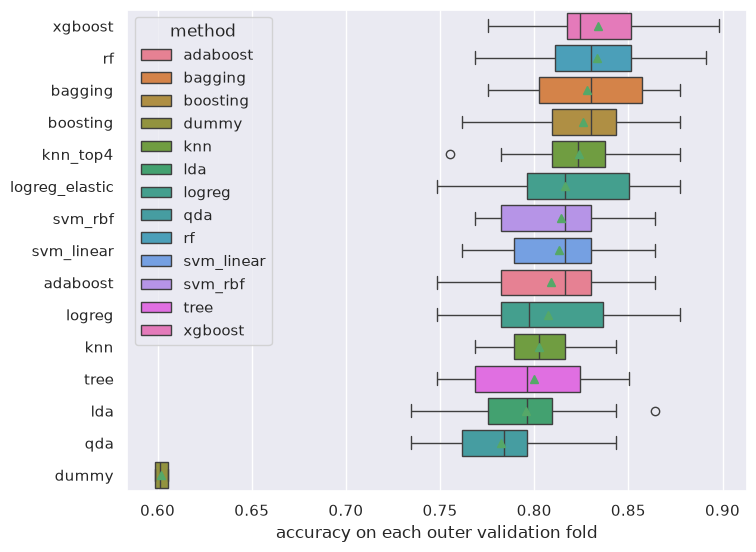

In [14]:
# Rev up the bugatti

best_choice = perform_modelling(path=RESULTS_PATH)

### Investigating interesting behaviour

<Axes: title={'center': 'boosting: learning_rate'}, xlabel='value', ylabel='accuracy'>

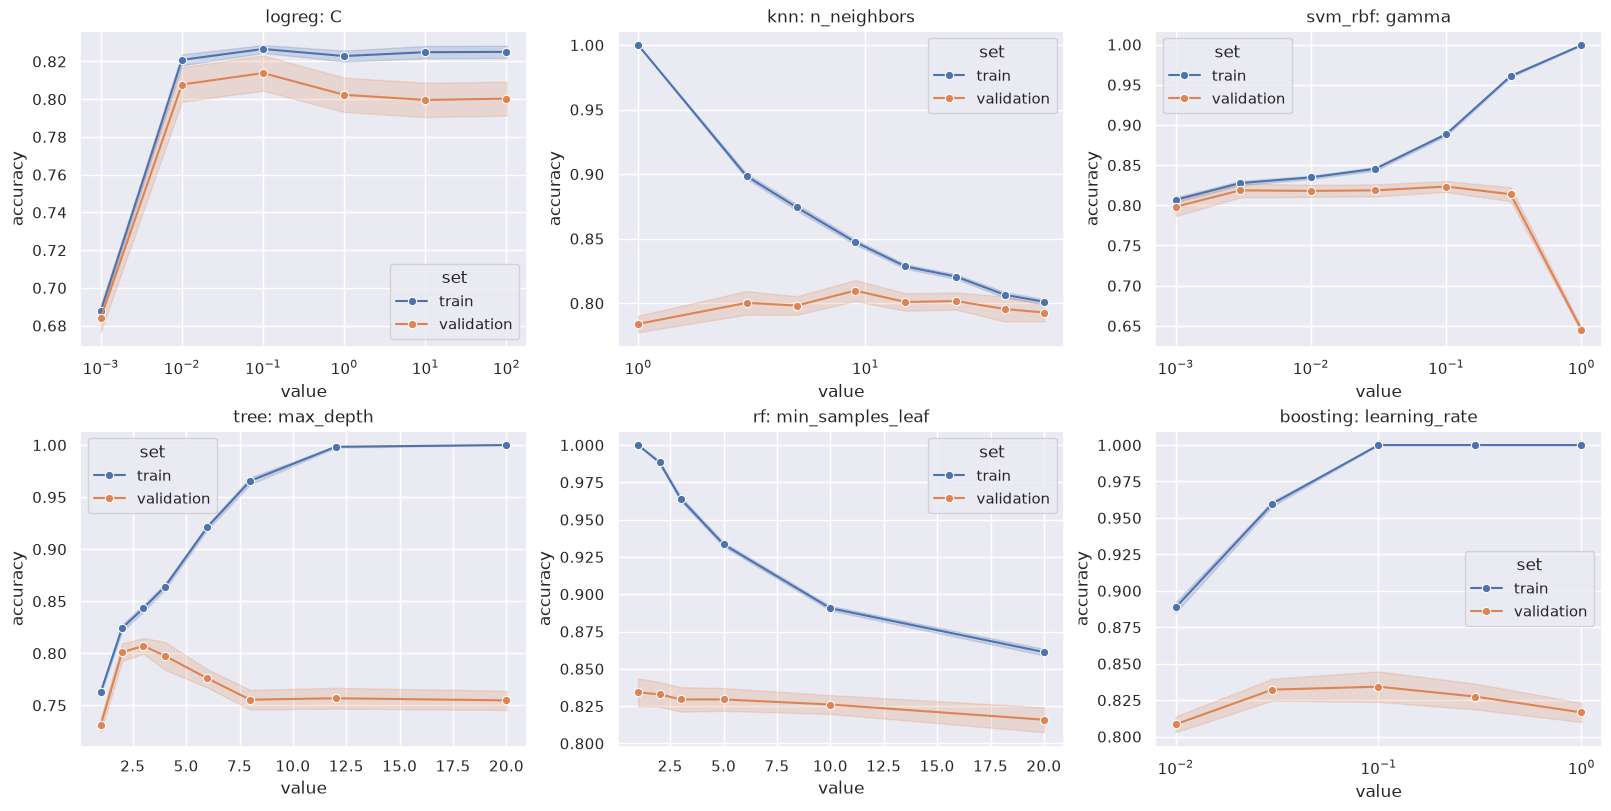

In [15]:
# Sweep some hyperparam and get plots of it, for some of the methods / variants

fig, axs = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
axs = np.atleast_1d(axs).ravel()
plot_validation_curve("logreg", "clf__C", [1e-3, 1e-2, 1e-1, 1, 10, 100], ax=axs[0])
plot_validation_curve("knn", "clf__n_neighbors", [1, 3, 5, 9, 15, 25, 41, 61], ax=axs[1])
plot_validation_curve("svm_rbf", "clf__gamma", [1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1], ax=axs[2])
plot_validation_curve("tree", "clf__max_depth", [1, 2, 3, 4, 6, 8, 12, 20], ax=axs[3])
plot_validation_curve("rf", "clf__min_samples_leaf", [1, 2, 3, 5, 10, 20], ax=axs[4])
plot_validation_curve("boosting", "clf__learning_rate", [0.01, 0.03, 0.1, 0.3, 1.0], ax=axs[5])

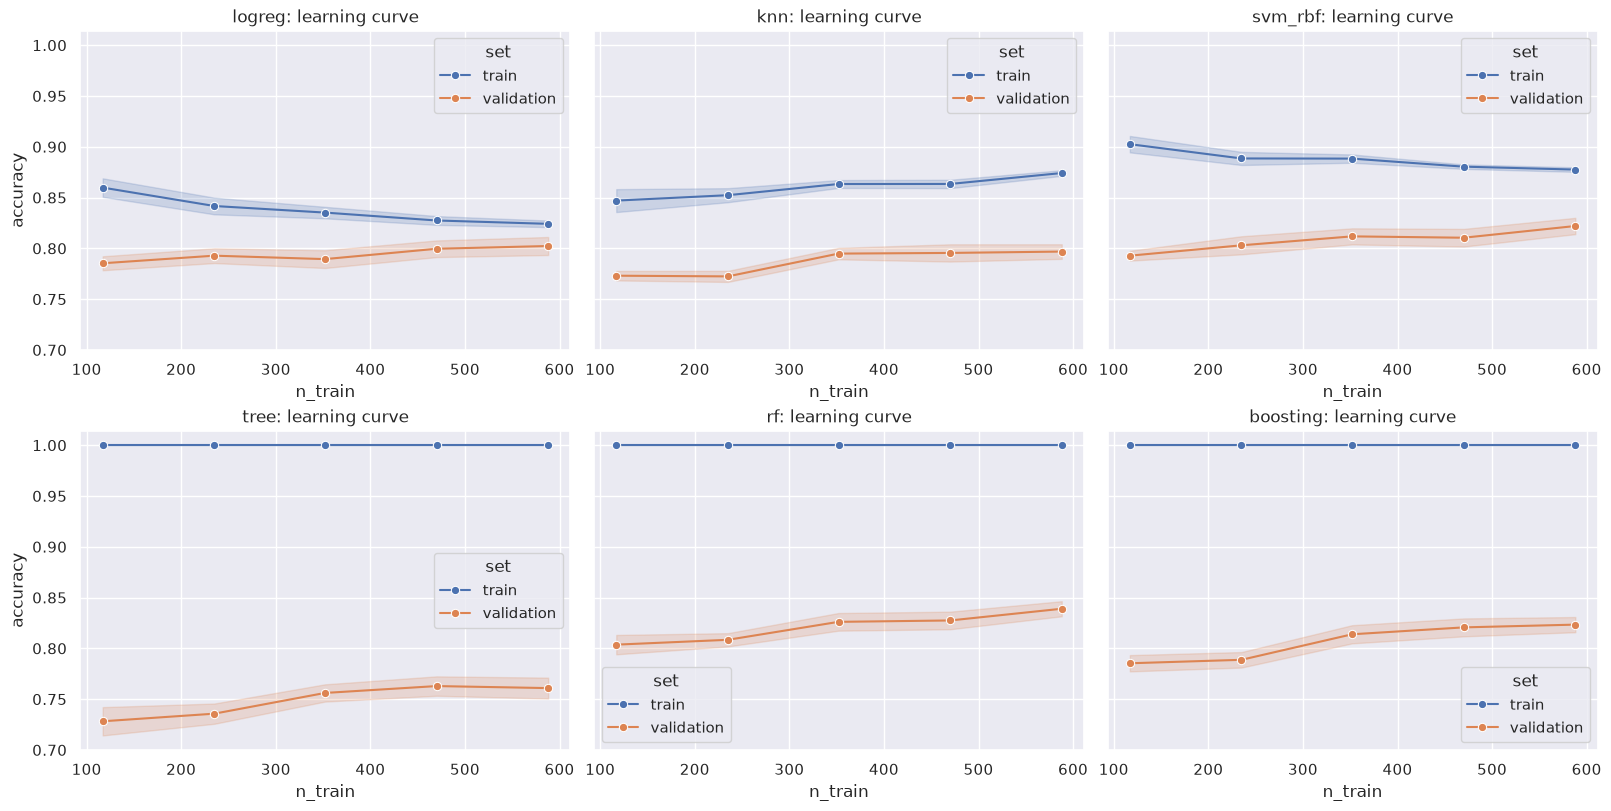

In [16]:
# Plot learning curves for some of the methods / variants
# NOTE: this uses the default values, and for tree-based variants
# this means unlimited depth for trees -> prone to overfitting

fig, axs = plt.subplots(2, 3, figsize=(16, 8), sharey=True, constrained_layout=True)
for ax, name in zip(np.atleast_1d(axs).ravel(), ["logreg", "knn", "svm_rbf", "tree", "rf", "boosting"]):
    plot_learning_curve(name, ax=ax)

variant,logreg,lda,knn,svm_rbf,rf,boosting
feature,,,,,,
speechiness,0.096,0.113,0.091,0.098,0.090,0.102
acousticness,0.024,0.024,0.047,0.026,0.025,0.043
loudness,0.025,0.001,0.015,0.027,0.027,0.033
danceability,0.008,0.011,0.037,0.028,0.010,0.024
energy,0.004,0.018,0.018,0.015,0.010,0.012
duration,0.008,0.000,0.009,0.004,0.008,0.011
instrumentalness,0.006,0.003,0.008,0.005,0.000,0.008
liveness,-0.001,-0.000,0.007,0.007,0.003,0.005
valence,-0.001,-0.001,-0.002,0.005,0.005,0.006


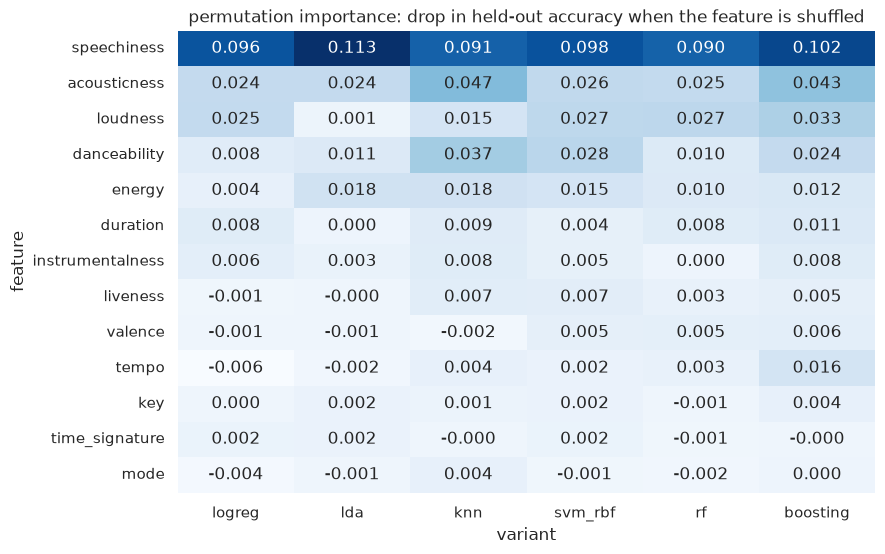

In [17]:
# Plot robust feature importances across models

importances = permutation_importances(["logreg", "lda", "knn", "svm_rbf", "rf", "boosting"])
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(importances, annot=True, fmt=".3f", cmap="Blues", cbar=False, ax=ax)
ax.set_title("permutation importance: drop in held-out accuracy when the feature is shuffled")
importances.round(3)

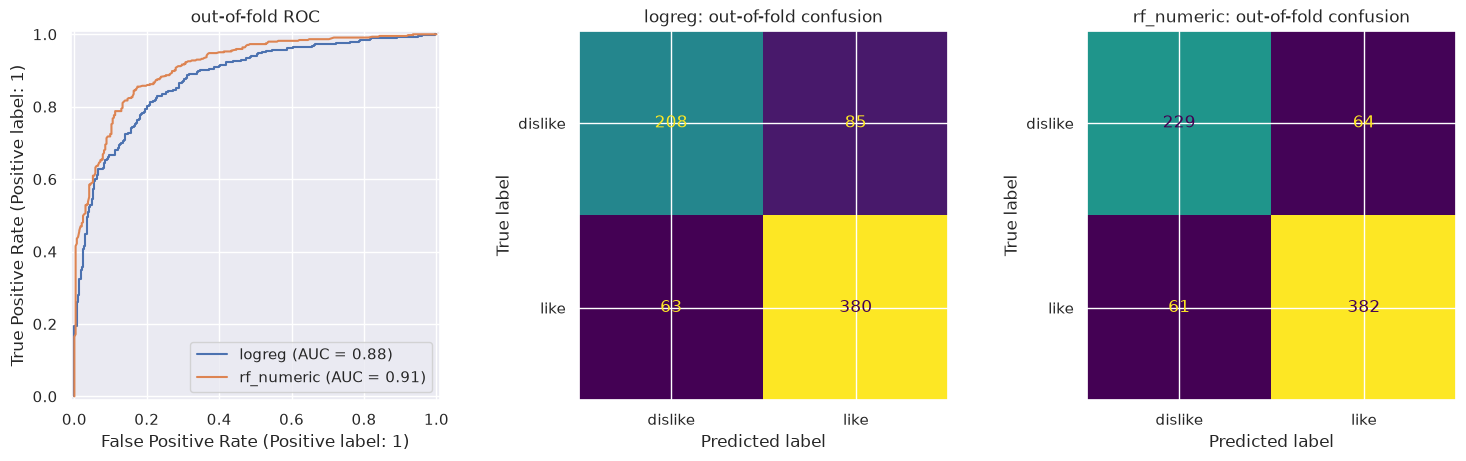

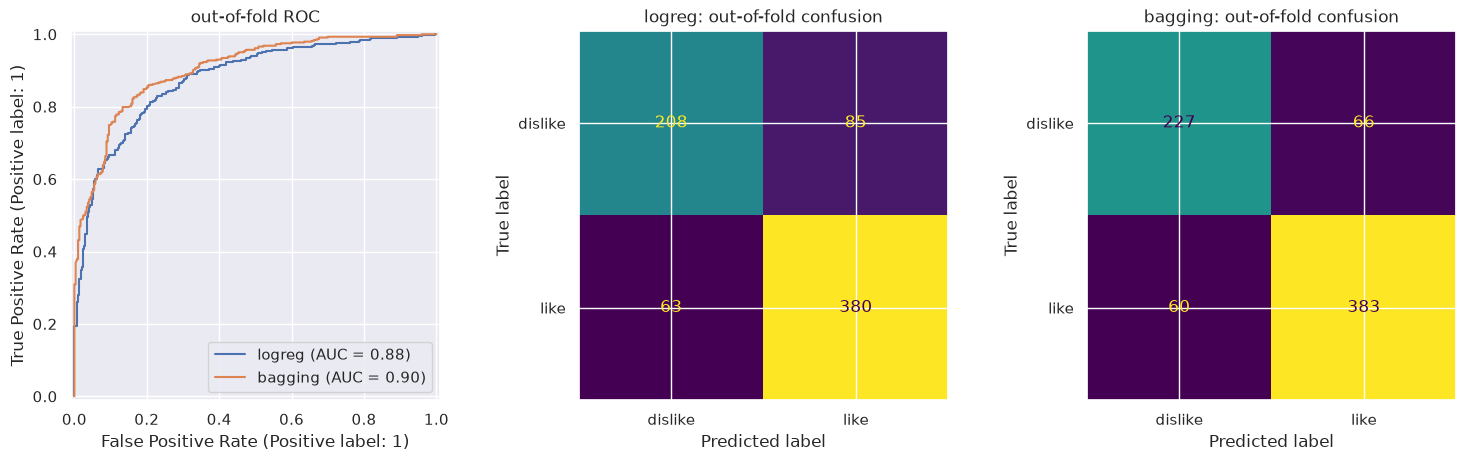

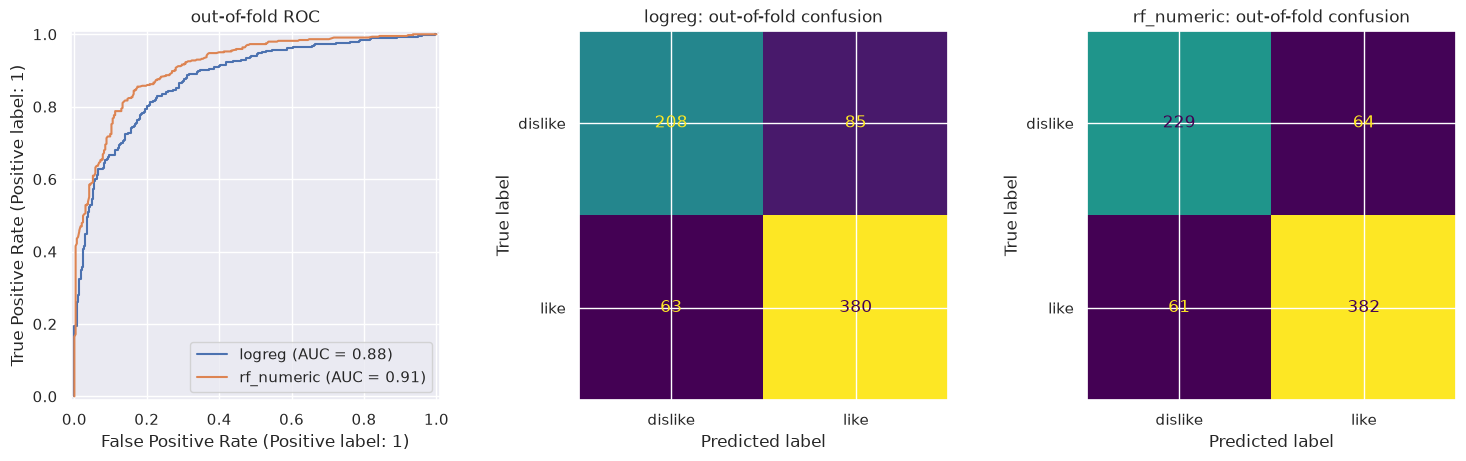

In [36]:
# Plot roc and confusion for logreg (basic choice) and our best choice

plot_roc_and_confusion(["logreg", best_choice]) # todo, after training
plot_roc_and_confusion(["logreg", "rf_numeric"]) # todo, after training

### Predicting the test set

In [20]:
def run_test_predictions(variant: str = best_choice, submission_path: str = "labs/lab_1_music_taste_prediction/submission.txt") -> str:
    """Run the final predictions to handin."""

    model = estimator_for(variant).fit(train_features, train_labels)
    if isinstance(model, GridSearchCV):
        print(variant, "refit with", chosen_params(model), f"(inner cv accuracy {model.best_score_:.3f})")

    prediction = model.predict(test_features)
    submission = "".join(str(int(p)) for p in prediction)
    assert len(submission) == 200 and set(submission) <= {"0", "1"}
    print(f"{submission.count('1')} liked of {len(submission)}")
    print(submission)

    with open(submission_path, "w") as f:
        f.write(submission + "\n")

In [ ]:
run_test_predictions(variant=best_choice, submission_path="labs/lab_1_music_taste_prediction/submission_best_choice.txt") # bagging
run_test_predictions(variant="rf_numeric", submission_path="labs/lab_1_music_taste_prediction/submission_rf_numeric.txt") # rf numeric

# I chose rf_numeric over the best_choice bc they were essentially equal, just that rf numeric had a slighly higher peak

bagging refit with {"estimator__min_samples_leaf": 1} (inner cv accuracy 0.832)
134 liked of 200
10010011001101101011101100000111011111010101110110001101100011100111101011110110110101111000011011111010110111110010101101111110101011111111101011001011001111111101111111111000111011111110101111110111
rf_numeric refit with {"max_features": 0.25, "min_samples_leaf": 3} (inner cv accuracy 0.844)
128 liked of 200
00010111001101101011101100001111011111010101110110001101100011100111101011110110110101110000011011111010010111110010101001111110101011111111101011001010001111111101111111111000011011111110100111100111
